In [2]:
# =====================================
# Step 1: Import Libraries
# =====================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [5]:
# =====================================
# Step 2: Load Dataset
# =====================================
data_df = pd.read_csv("heart_failure_clinical_records_dataset.csv")


In [6]:
# =====================================
# Step 3: Basic Data Exploration
# =====================================
print(data_df.head())
print(data_df.info())
print(data_df.describe())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [7]:
# =====================================
# Step 4: Missing Values
# =====================================
print(data_df.isnull().sum())


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [8]:
# =====================================
# Step 5: Class Distribution
# =====================================
print(data_df["DEATH_EVENT"].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


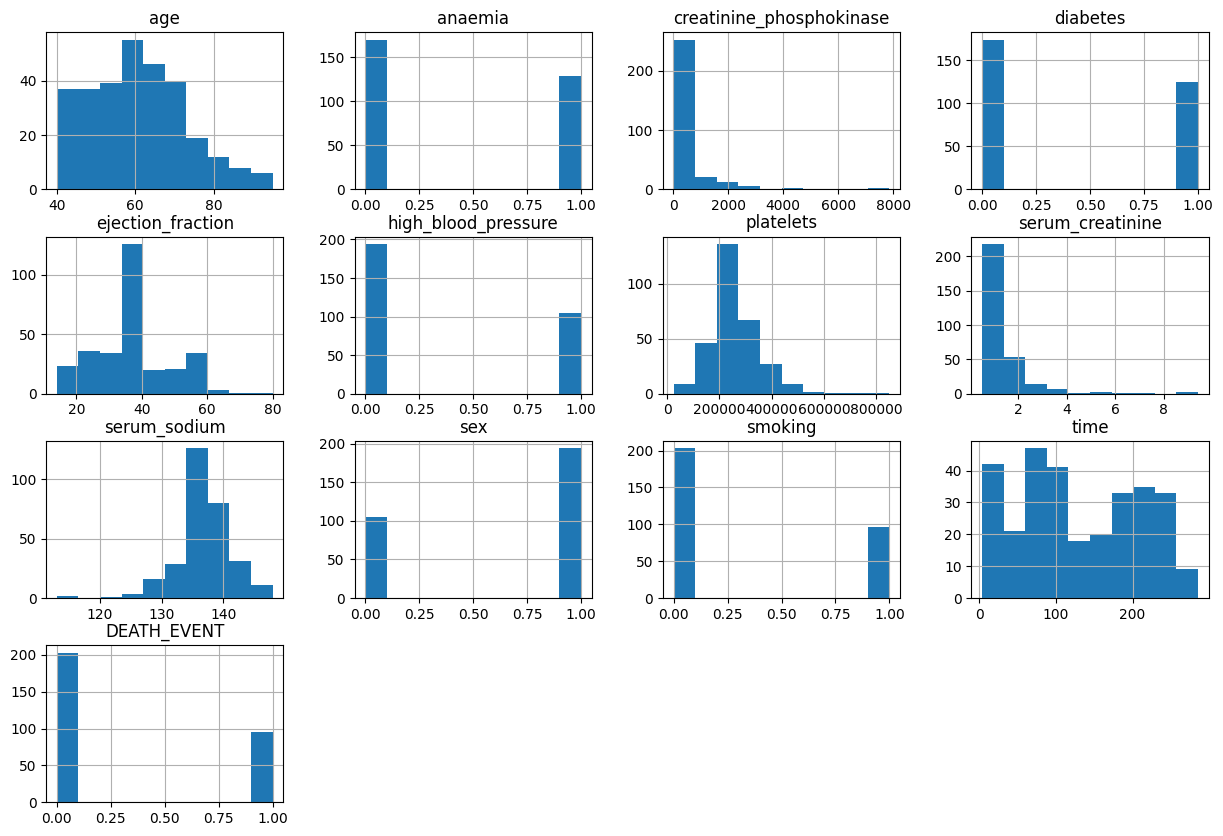

In [10]:
# =====================================
# Step 6: Histogram Plot
# =====================================
data_df.hist(figsize=(15,10))
plt.show()

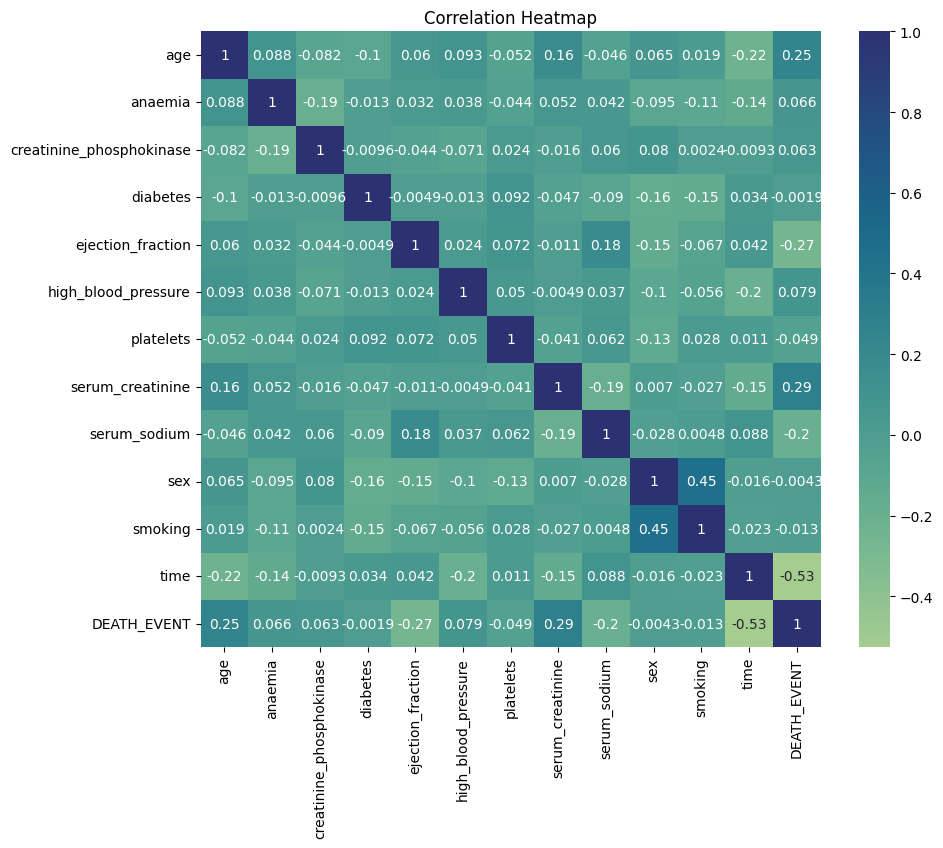

In [12]:
# =====================================
# Step 7: Correlation Heatmap
# =====================================
plt.figure(figsize=(10,8))

sns.heatmap(
    data_df.corr(),
    annot=True,
    cmap="crest"
)

plt.title("Correlation Heatmap")
plt.show()

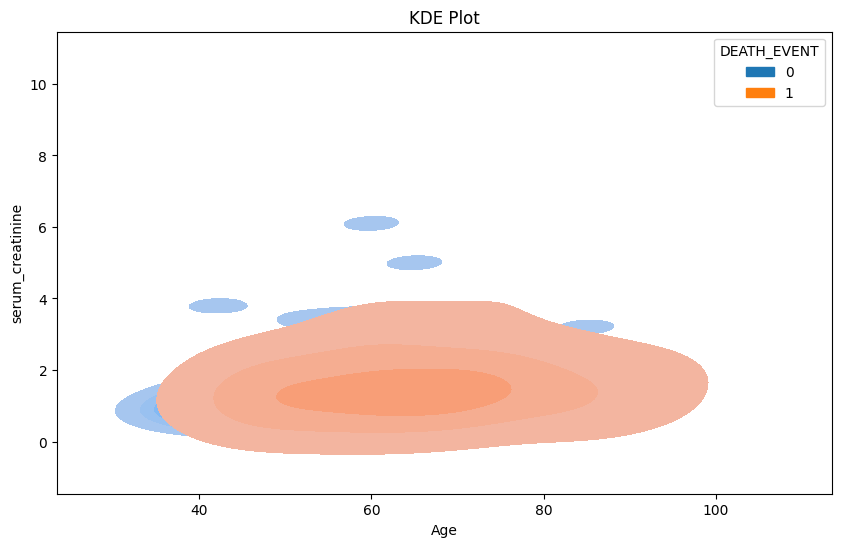

In [14]:
# =====================================
# Step 8: KDE Plot
# =====================================
plt.figure(figsize=(10,6))

sns.kdeplot(
    x=data_df["age"],
    y=data_df["serum_creatinine"],
    hue=data_df["DEATH_EVENT"],
    fill=True
)

plt.title("KDE Plot")
plt.xlabel("Age")
plt.ylabel("serum_creatinine")

plt.show()

In [15]:
# =====================================
# Step 9: Feature & Target Split
# =====================================
X = data_df.drop("DEATH_EVENT", axis=1)
y = data_df["DEATH_EVENT"]

In [16]:
# =====================================
# Step 10: Train-Test Split
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# =====================================
# Step 11: Feature Scaling
# =====================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
# =====================================
# Step 12: Train SVM Model
# =====================================
model = SVC(kernel="sigmoid")
model.fit(X_train, y_train)

SVC(kernel='sigmoid')

In [21]:
# =====================================
# Step 13: Prediction & Evaluation
# =====================================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7666666666666667
